In [1]:
import jax
import matplotlib.pyplot as plt
import numpy as np
import optax
from flax import nnx

from qmodem import LSTM, CMAPSSAnalyst, create_dataloaders, split_cmapss
from qmodem.module import mc_sample
from qmodem.train import EarlyStopper, train_loop
from qmodem.utils import get_statistics

BATCH_SIZE = 10
DROPUT_RATE = 0.3
HIDDEN_SIZE = 40
LR = 1e-3
N_EPOCHS = 100
NUM_MC_SAMPLES = 10
NUM_SENSORS = 9
PATIENCE = 10
PRINT_EVERY = 10
SEED = 42
TIME_WINDOW_SIZE = 30

np.random.seed(SEED)

In [2]:
analyst = CMAPSSAnalyst(
    relative_test_size=0.2
)  # the analyst splits the data already into `train_` and `test_`

train_df, test_df = analyst.train_df, analyst.test_df

# do another split for the validation set.
train_df, val_df = split_cmapss(train_df, relative_subset_size=0.3)

The analyst can compute the prognostic metrics of the different sensors, which will help retaining only those sensors which are most useful for prognostics.

In [3]:
metrics_cmapss = analyst.compute_prognostic_metrics()
metrics_cmapss

,sensor_name,monotonicity,prognosability,trendability,fitness
0,sensor_11,0.811471,0.868111,0.019371,0.566318
1,sensor_12,-0.783066,0.843485,0.020273,0.548941
2,sensor_4,0.771310,0.871807,0.000436,0.547851
3,sensor_7,-0.751420,0.838661,0.001006,0.530362
4,sensor_15,0.710282,0.840112,0.000562,0.516985
5,sensor_20,-0.705609,0.827961,0.000794,0.511455
6,sensor_21,-0.699806,0.808456,0.000245,0.502836
7,sensor_2,0.661837,0.814902,0.000231,0.492323
8,sensor_17,0.644804,0.783602,0.000216,0.476208
9,sensor_3,0.631791,0.763712,0.000569,0.465357


Select the 9 sensors with the highest fitness.

In [4]:
analyst.train_df.head()

,unit_id,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
10980,56,1,-0.0009,-0.0005,100.0,642.57,1591.56,1405.96,553.34,2388.12,9055.81,47.38,521.93,2388.10,8133.85,8.4444,391,38.75,23.3174,274
10981,56,2,0.0012,-0.0004,100.0,642.75,1586.44,1415.44,552.68,2388.10,9059.10,47.72,521.18,2388.13,8136.92,8.4412,395,38.81,23.2391,273
10982,56,3,0.0012,-0.0004,100.0,642.47,1584.96,1410.81,552.90,2388.12,9057.99,47.42,520.82,2388.08,8133.11,8.4461,394,38.82,23.3340,272
10983,56,4,0.0026,0.0005,100.0,642.52,1587.64,1403.70,553.52,2388.13,9054.91,47.48,521.70,2388.12,8136.86,8.4357,394,38.89,23.2844,271
10984,56,5,0.0034,-0.0002,100.0,642.51,1587.80,1411.17,553.60,2388.13,9045.30,47.49,522.06,2388.18,8132.53,8.4411,394,38.79,23.3204,270


In [5]:
sensors_selected = metrics_cmapss.head(NUM_SENSORS)["sensor_name"].tolist()

# filter the dataframes to only include the selected sensors (exclude also the operati)
non_sensor_columns = [
    col
    for col in analyst.column_names
    if not (col.startswith("sensor") or col.startswith("op_setting"))
]
columns_selected = non_sensor_columns + sensors_selected
train_df = train_df[columns_selected]
val_df = val_df[columns_selected]
test_df = test_df[columns_selected]

In [6]:
train_df.head()

,unit_id,time_cycles,RUL,sensor_11,sensor_12,sensor_4,sensor_7,sensor_15,sensor_20,sensor_21,sensor_2,sensor_17
10980,56,1,274,47.38,521.93,1405.96,553.34,8.4444,38.75,23.3174,642.57,391
10981,56,2,273,47.72,521.18,1415.44,552.68,8.4412,38.81,23.2391,642.75,395
10982,56,3,272,47.42,520.82,1410.81,552.90,8.4461,38.82,23.3340,642.47,394
10983,56,4,271,47.48,521.70,1403.70,553.52,8.4357,38.89,23.2844,642.52,394
10984,56,5,270,47.49,522.06,1411.17,553.60,8.4411,38.79,23.3204,642.51,394


Now, we can use the `CMAPSSDataSource` class to prepare the feature/label arrays for the train and test dataframes.
We use a standard scaler to bring the features to zero mean and variance = 1, in order to prevent the different scales of the features to condition the training.
We also define a time-window the histories, with a window length large enough to reveal degradation and small enough to prevent overfitting and have enough training samples.

In [7]:
from sklearn.preprocessing import StandardScaler

from qmodem.data import CMAPSSDataSource

scaler = StandardScaler()

# Note, scaling happens at init time, so when the same scaler is passed to the test datasource, it will use the
# statistics computed on the training data to scale the test data.
ds_train = CMAPSSDataSource(
    train_df, train_or_test="train", scaler=scaler, window_size=TIME_WINDOW_SIZE
)
ds_val = CMAPSSDataSource(
    val_df, train_or_test="test", scaler=scaler, window_size=TIME_WINDOW_SIZE
)
ds_test = CMAPSSDataSource(
    test_df, train_or_test="test", scaler=scaler, window_size=TIME_WINDOW_SIZE
)

With the training and validation data sources, we define the dataloaders for batching during training.

In [8]:
dl_train, dl_val = create_dataloaders(
    ds_train=ds_train,
    ds_val=ds_val,
    batch_size=BATCH_SIZE,
    seed_train=SEED,
    seed_val=SEED + 1,
    shuffle_train=False,
    shuffle_val=False,
)

Now we can define the data-processing model of our application. This has two LSTM layers, dropout after the LSTMs and a final dense layer. The dense layer reduces the feature dimension to a single output.

First, we will see just how the model processes a batch of inputs.

In [9]:
model = LSTM(
    input_size=NUM_SENSORS,
    hidden_size=HIDDEN_SIZE,
    rngs=nnx.Rngs(0),
)

x0, y0 = next(iter(dl_train))
print(f"Input shape: {x0.shape}, target shape: {y0.shape}")
print(f"Model output shape: {model(x0, rngs=nnx.Rngs(0)).shape}")
print(y0)

Input shape: (10, 30, 9), target shape: (10, 1)
Model output shape: (10, 1)
[[245]
 [244]
 [243]
 [242]
 [241]
 [240]
 [239]
 [238]
 [237]
 [236]]


At this point, we do the usual training setup (same as what we did for the battery RUL case).

In [10]:
schedule = optax.cosine_decay_schedule(
    init_value=LR,
    decay_steps=N_EPOCHS * (len(ds_train) // BATCH_SIZE),
    alpha=0.1,
)
optimizer = nnx.Optimizer(model, optax.adam(schedule), wrt=nnx.Param)
early_stopper = EarlyStopper(patience=PATIENCE, min_delta=1e-4)


def mse_loss(model: nnx.Module, batch: jax.Array):
    x, y = batch
    y_pred = model(x, rngs=nnx.Rngs(0))
    return ((y - y_pred) ** 2).mean()


@nnx.jit
def train_step(model: nnx.Module, optimizer: nnx.Optimizer, batch: jax.Array):
    def loss_fn(model):
        return mse_loss(model, batch)

    loss, grads = nnx.value_and_grad(loss_fn)(model)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model: nnx.Module, batch: jax.Array):
    return mse_loss(model, batch)

Let's also define a callback `on_validation_improvement` that stores the state of the model when the validation loss improves.

In [11]:
model_state_best = nnx.state(model, nnx.Param)  # initial model state


def on_validation_improvement():
    global model_state_best
    model_state_best = nnx.state(model, nnx.Param)

And we're ready to train!

In [12]:
best_val_loss, _ = train_loop(
    n_epochs=N_EPOCHS,
    dataloader_train=dl_train,
    dataloader_val=dl_val,
    train_batch_fn=lambda batch: train_step(model, optimizer, batch),
    eval_batch_fn=lambda batch: eval_step(model, batch),
    early_stopper=early_stopper,
    print_every=PRINT_EVERY,
    on_train_epoch_start=model.train,
    on_val_epoch_start=model.eval,
    on_validation_improvement=on_validation_improvement,
)

Epoch   1/100 | Train Loss: 8455.593750 | Val Loss: 8741.581055
Epoch  10/100 | Train Loss: 1845.690308 | Val Loss: 2606.472900
Epoch  20/100 | Train Loss: 1311.901855 | Val Loss: 1997.324463
Epoch  30/100 | Train Loss: 1055.866577 | Val Loss: 1965.045288
Epoch  40/100 | Train Loss: 848.204407 | Val Loss: 1861.017944
Epoch  50/100 | Train Loss: 713.569092 | Val Loss: 1768.353271
Epoch  60/100 | Train Loss: 598.962219 | Val Loss: 1845.867432
Early stopping triggered at epoch 66. Validation loss: 1837.4851
Training complete! Best validation loss: 1749.923950



At the end of training, we restore the best state, in case early stopping has occurred.

In [13]:
nnx.update(model, model_state_best)

We can now pick the test cases from the split we did `CMAPSS/FD001/Train` and verify that the LSTM has learned the jet-engines RUL.

We will do this in two different ways:
1. Eval mode, where we will deactivate dropout and have no stochasticity on the prediction.
2. Train/MCD mode, where dropout will stay active and we will sample the trained model.

In [14]:
test_df["unit_id"].unique()

[84, 54, 71, 46, 45, ..., 5, 77, 78, 13, 32]
Length: 20
Categories (100, int64): [84 < 54 < 71 < 46 ... 72 < 15 < 93 < 52]

In [15]:
def plot_rul_deterministic(unit_id: int, ax: plt.Axes) -> None:
    X_u, y_u = ds_test.get_unit_arrays(unit_id=unit_id, window_size=TIME_WINDOW_SIZE)

    # Also get the time cycles for plotting, remembering to skip the first window to match
    # the times of the targets.
    t_u = test_df[test_df["unit_id"] == unit_id]["time_cycles"].values[
        TIME_WINDOW_SIZE - 1 :
    ]

    model.eval()
    y_pred_u = model(X_u, rngs=nnx.Rngs(0))

    ax.plot(t_u, y_u, label="True RUL")
    ax.plot(t_u, y_pred_u, label="Predicted RUL (LSTM)")
    ax.set_xlabel("Time Cycles")
    ax.set_ylabel("Remaining Useful Life (RUL)")
    ax.set_title(f"True vs Predicted RUL for Unit {unit_id}")
    ax.grid()
    ax.legend()

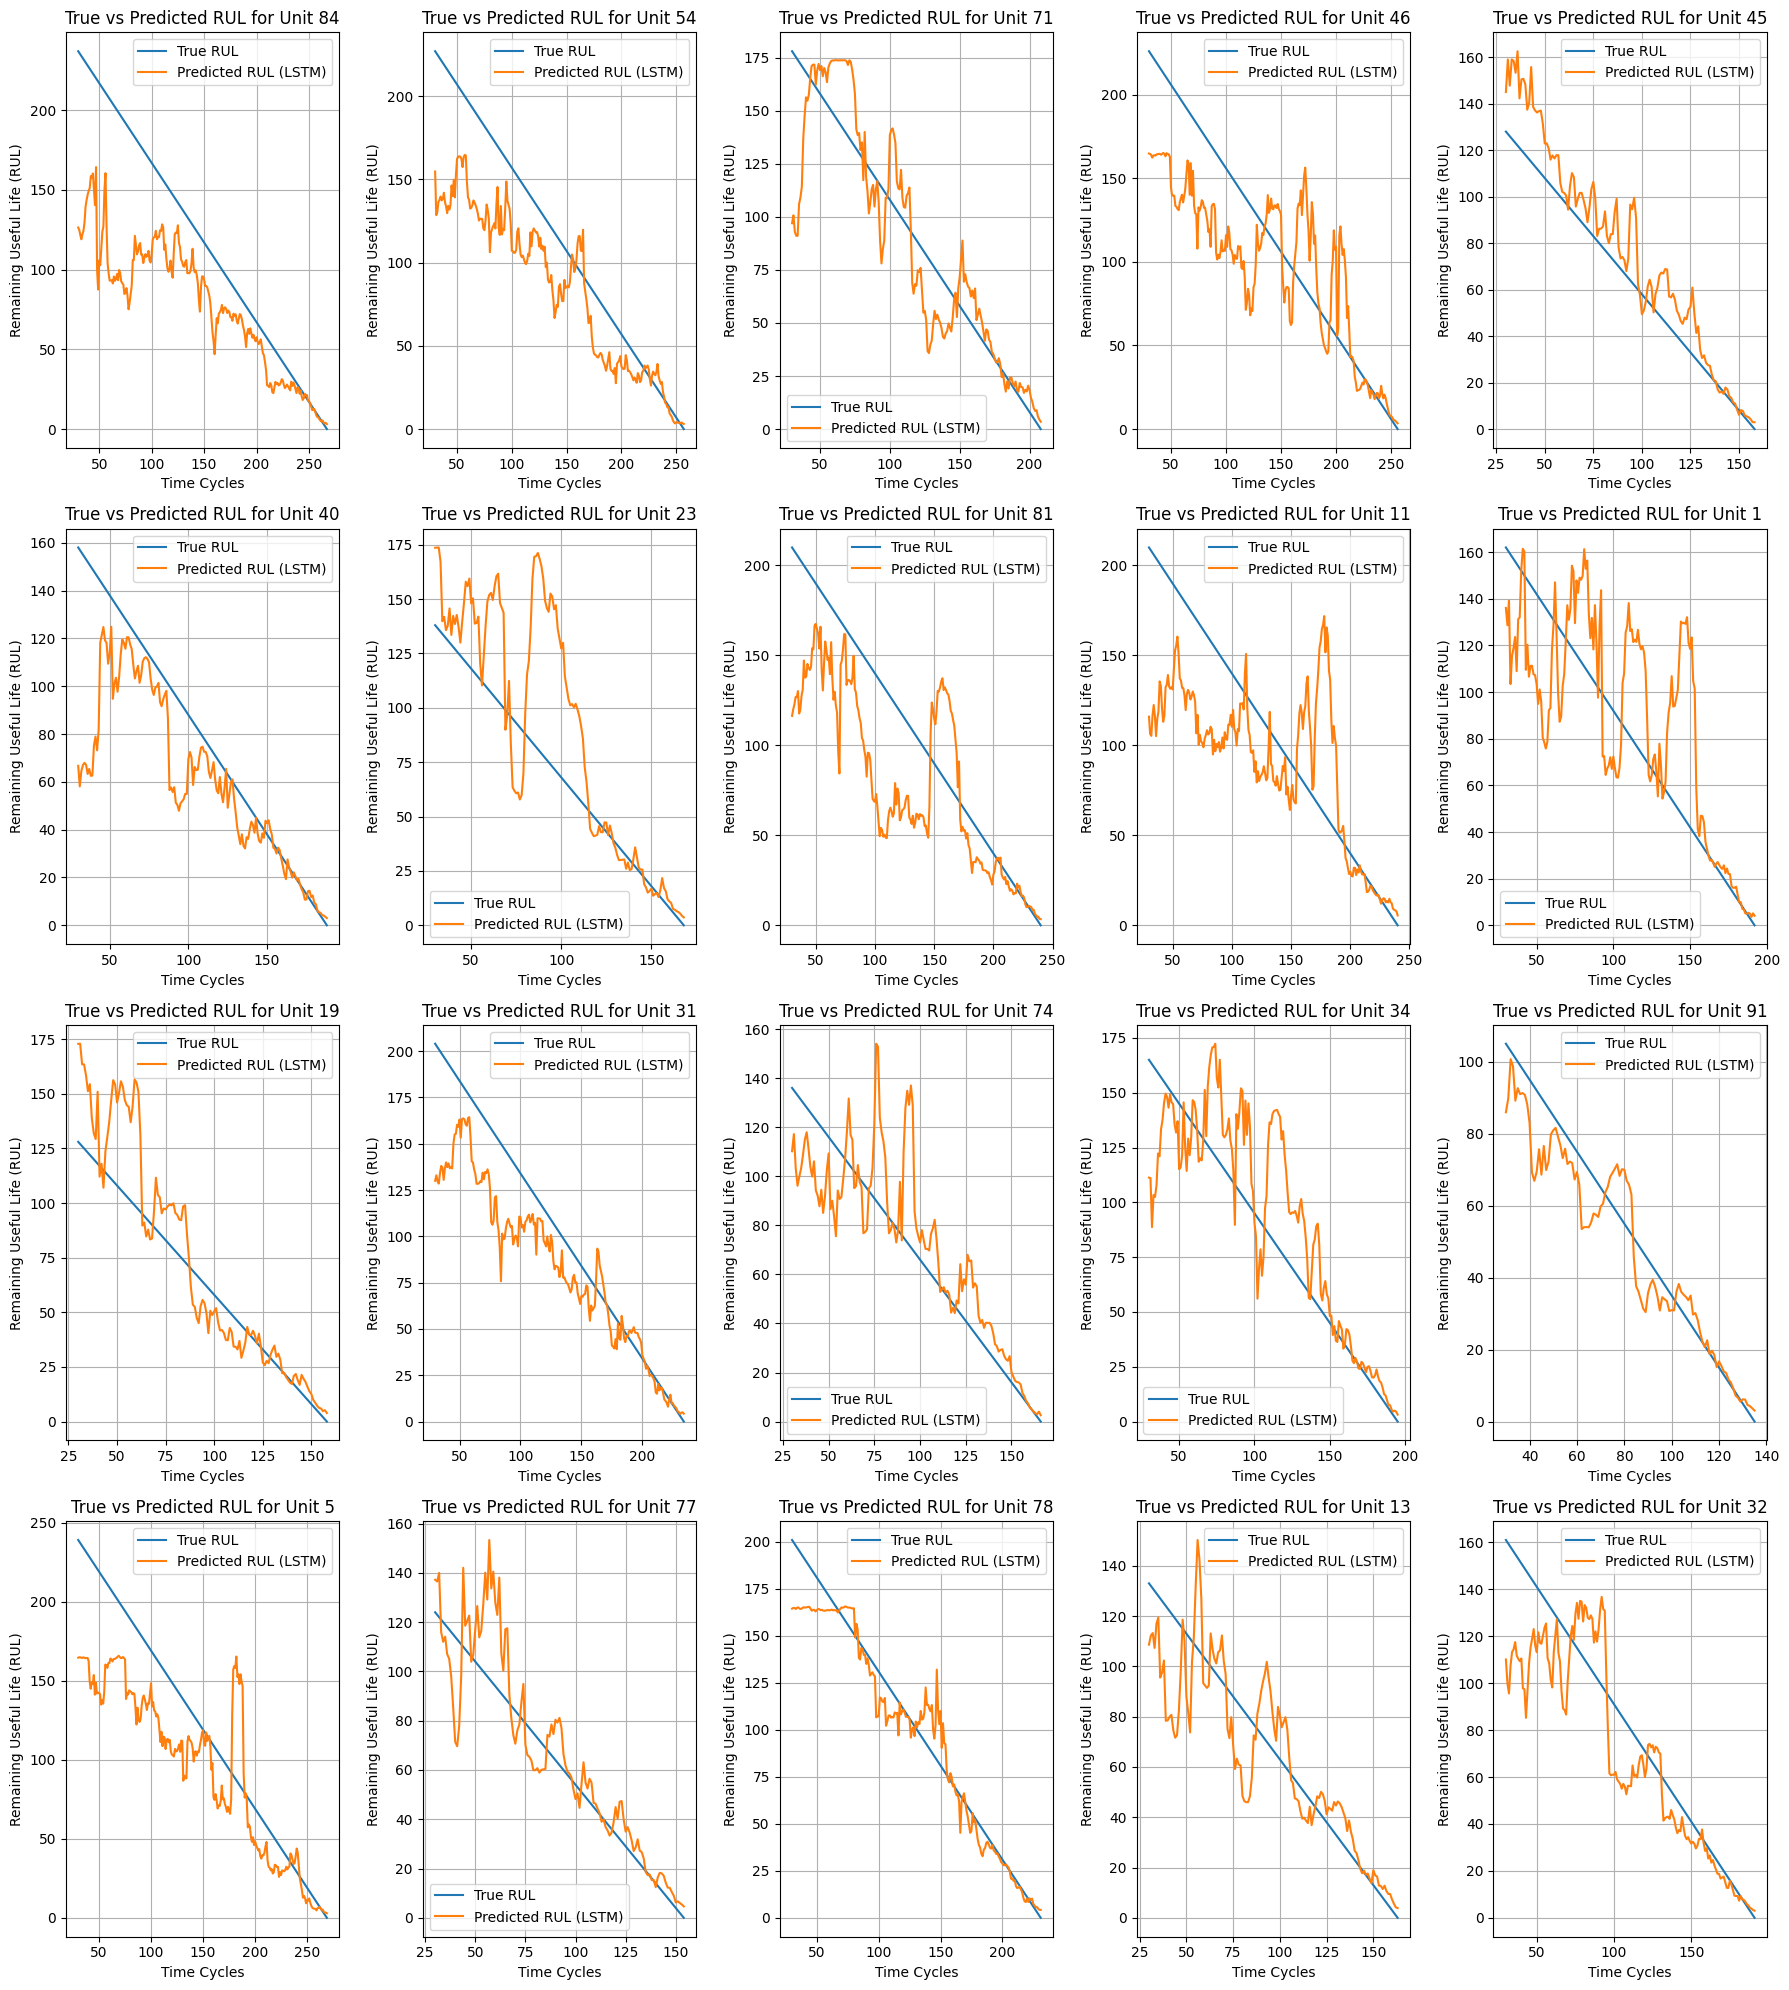

In [16]:
fig, axs = plt.subplots(4, 5, figsize=(18, 20))

for unit_id, ax in zip(test_df["unit_id"].unique(), axs.flatten()):
    plot_rul_deterministic(unit_id=unit_id, ax=ax)

fig.tight_layout()

For the MCD mode we need to take multiple samples for each input `x`, corresponding to different dropout activations.

We must ensure that the random dropout activations are independent from the samples.

We will use `jax.vmap` to vectorize over the random keys (for dropout) and over `x`.

In [17]:
def plot_rul_stochastic(unit_id: int, ax: plt.Axes, base_key_seed: int) -> None:
    X_u, y_u = ds_test.get_unit_arrays(unit_id=unit_id, window_size=TIME_WINDOW_SIZE)
    t_u = test_df[test_df["unit_id"] == unit_id]["time_cycles"].values[
        TIME_WINDOW_SIZE - 1 :
    ]

    keys = jax.random.split(jax.random.key(base_key_seed), NUM_MC_SAMPLES)

    model.train()  # we are not actually training, but the `train` mode makes the dropout stochastic

    y_pred_samples = mc_sample(model, X_u, keys)  # shape (time, num_samples, 1)
    stats = get_statistics(y_pred_samples, dim=1)

    ax.plot(t_u, y_u, label="True RUL")
    ax.plot(t_u, stats.mean, label="Predicted mean RUL (LSTM)")
    ax.fill_between(
        t_u,
        stats.p_025.flatten(),
        stats.p_975.flatten(),
        color="orange",
        alpha=0.3,
        label="95% CI",
    )
    ax.set_xlabel("Time Cycles")
    ax.set_ylabel("Remaining Useful Life (RUL)")
    ax.set_title(f"True vs Predicted RUL for Unit {unit_id}")
    ax.grid()
    ax.legend()

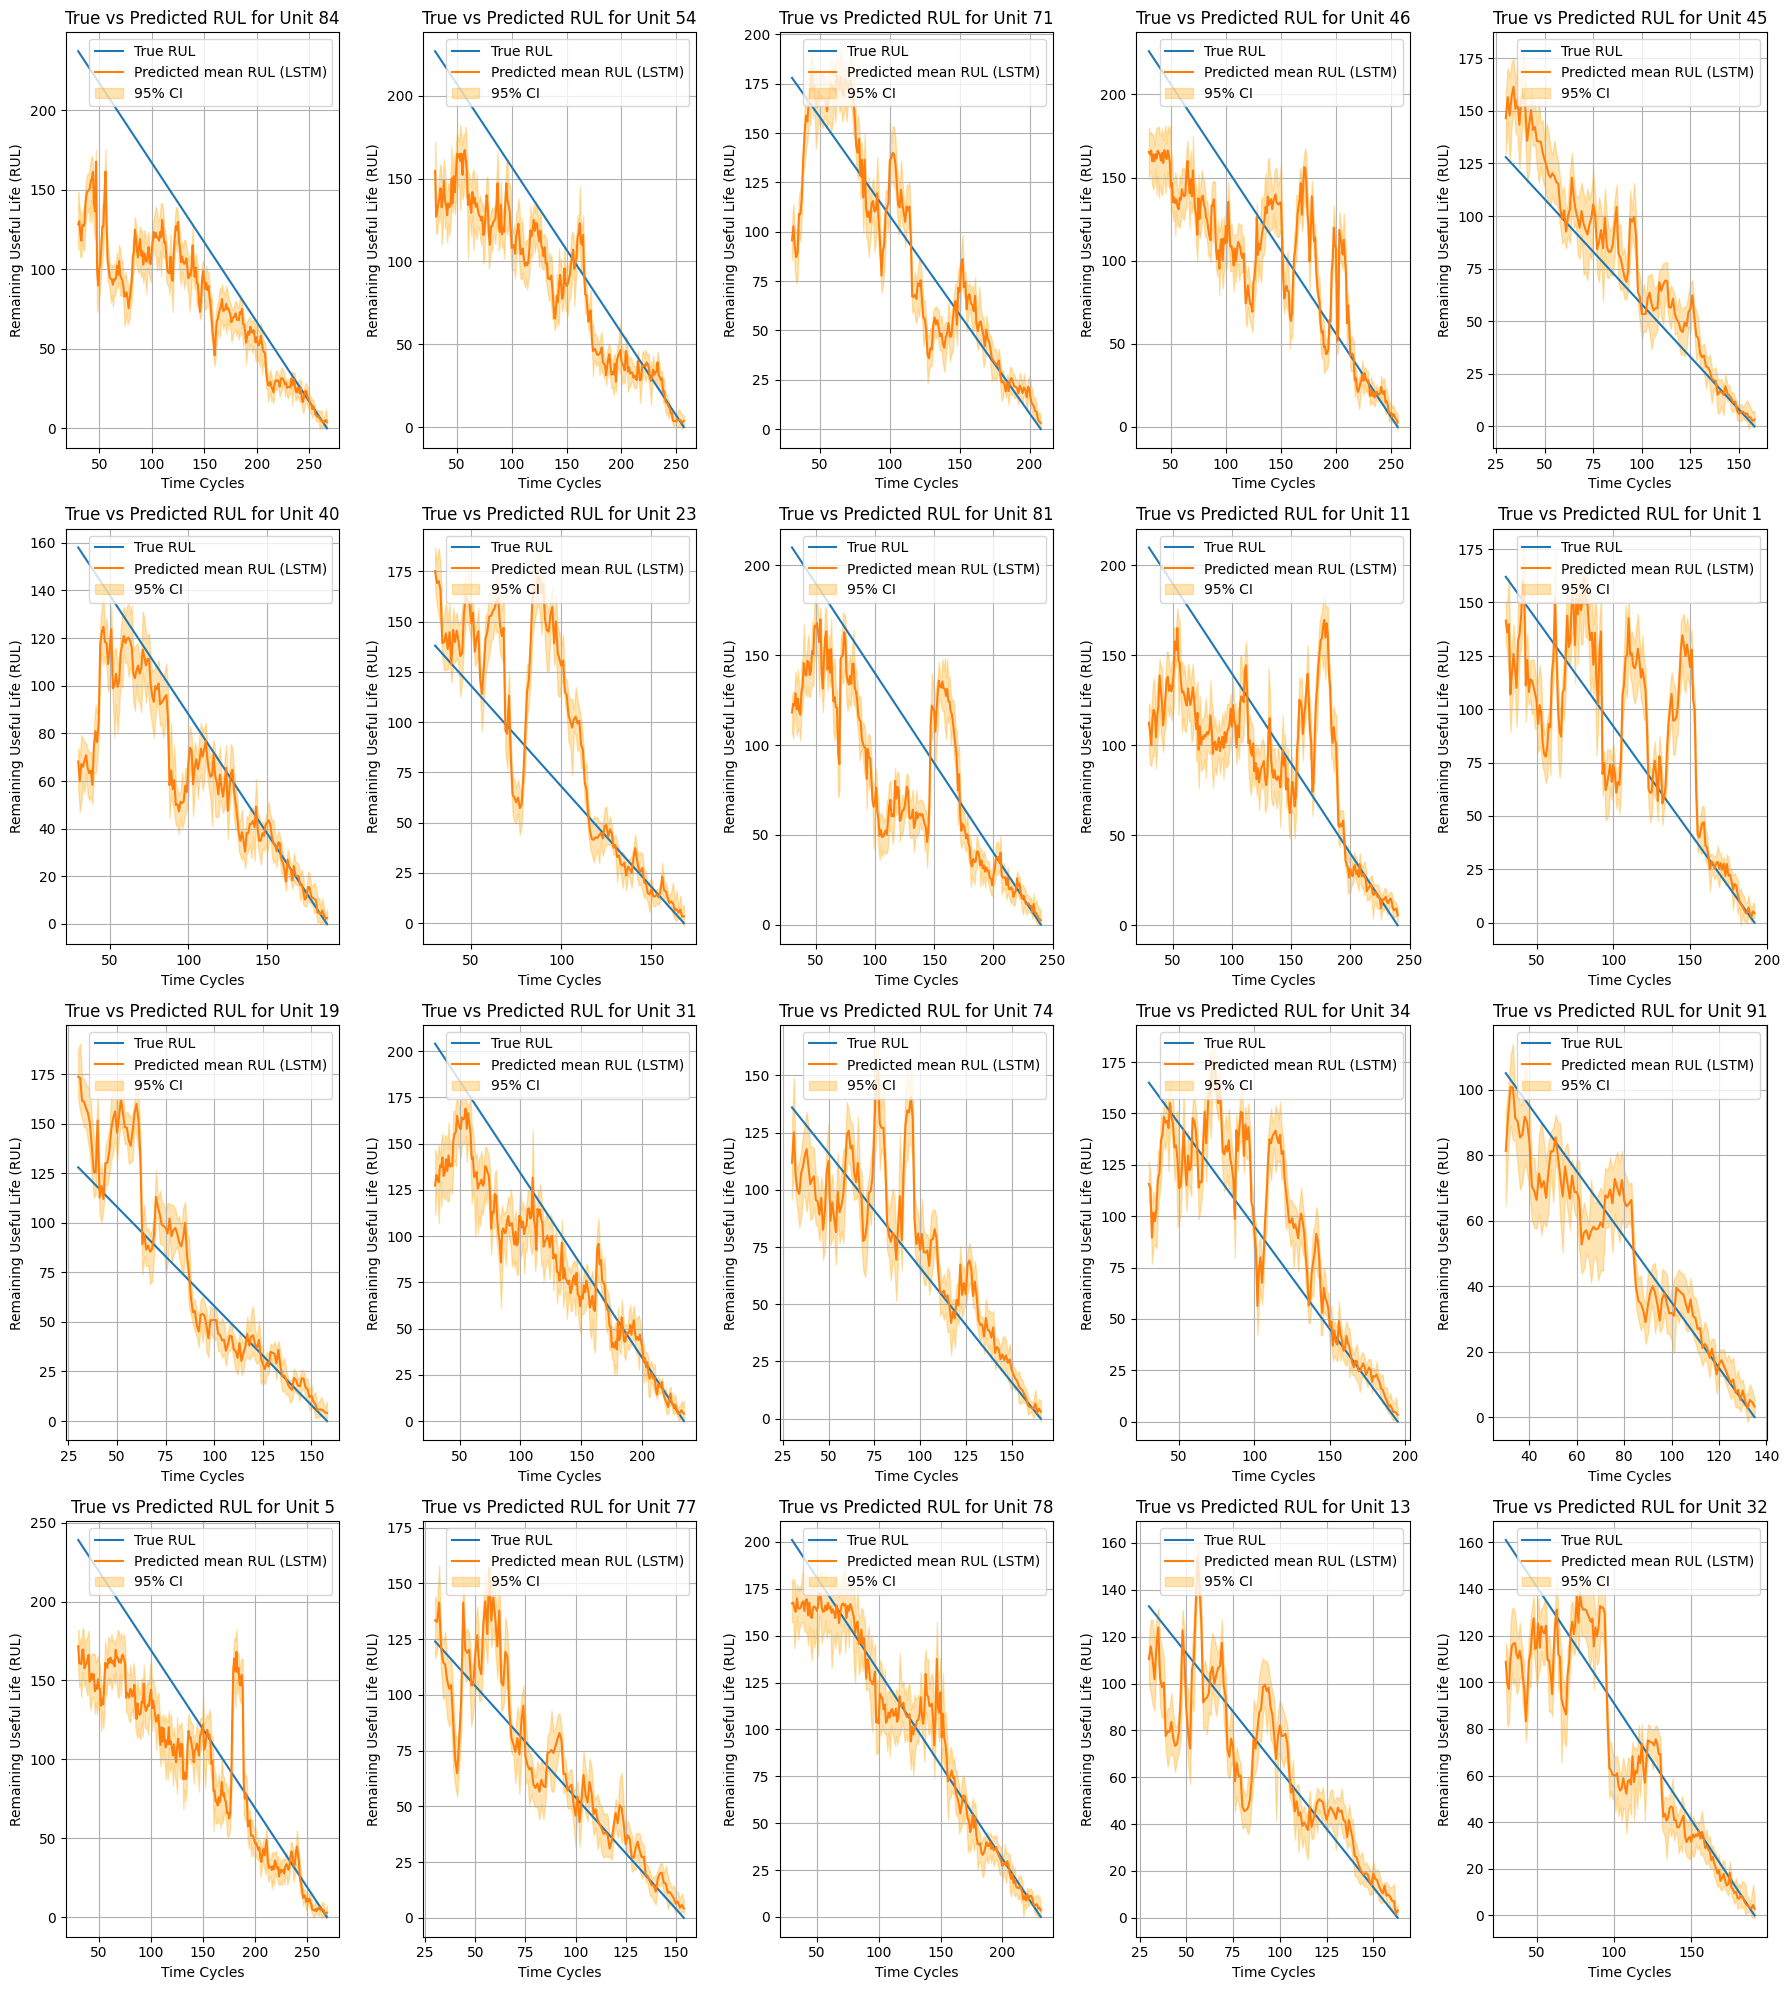

In [18]:
fig, axs = plt.subplots(4, 5, figsize=(18, 20))

for unit_id, ax, base_seed in zip(
    test_df["unit_id"].unique(), axs.flatten(), range(20)
):
    plot_rul_stochastic(unit_id=unit_id, ax=ax, base_key_seed=base_seed)

fig.tight_layout()